# EDA de Housing Prices

Este notebook realiza uma análise exploratória do conjunto de dados de casas de Ames, Iowa, com foco em entender quais variáveis mais se relacionam com `SalePrice` e podem ser úteis para a previsão do preço final.

A estrutura do notebook segue três análises de tipos de variáveis diferentes: numéricas, categóricas e ordinais. Ao longo do processo, também tratamos valores ausentes e verificamos distribuições, outliers e padrões relevantes para futura modelagem.

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

houses = pd.read_csv('houses.csv', keep_default_na=False, na_values=['NA',''])
houses.head()

# Aqui, defini que apenas "NA" e '' serão considerados como valores nulos
# "None" não será considerado nulo pois, em todas colunas que aparece, tem significado

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## **Verificação de Valores Nulos e Imputação**

Nesta etapa, realizamos uma verificação dos valores nulos no conjunto de dados para identificar quais colunas possuem informações em falta e a gravidade de cada caso. O código calcula a quantidade exata e o percentual de linhas vazias em cada variável, exibindo um relatório ordenado das colunas com mais problemas para as com menos. Esse diagnóstico é fundamental porque nos dá uma visão clara do estado de integridade dos dados, permitindo planejar e aplicar com segurança as melhores estratégias de tratamento (como o preenchimento por mediana ou por categorias padrão) antes de avançar para os gráficos e modelagens.

In [33]:
def print_null_info(df):
    num_nulls = df.isnull().sum()
    num_nulls = num_nulls[num_nulls > 0]

    if num_nulls.empty:
        print("[INFO] Diagnóstico concluído: Não existem valores nulos no DataFrame.")
        return

    percent_nulls = (num_nulls / len(df)) * 100

    null_values_df = pd.DataFrame({
        'Variável': num_nulls.index,
        'Total Nulos (Absoluto)': num_nulls.values,
        'Proporção (%)': percent_nulls.values
    })

    null_values_df = null_values_df.sort_values(by='Total Nulos (Absoluto)', ascending=False).reset_index(drop=True)

    print("=== RELATÓRIO DE INTEGRIDADE: DADOS AUSENTES ===")
    print(null_values_df.to_string(index=False, formatters={'Proporção (%)': '{:,.2f}%'.format}))


print_null_info(houses)

=== RELATÓRIO DE INTEGRIDADE: DADOS AUSENTES ===
    Variável  Total Nulos (Absoluto) Proporção (%)
      PoolQC                    1453        99.52%
 MiscFeature                    1406        96.30%
       Alley                    1369        93.77%
       Fence                    1179        80.75%
 FireplaceQu                     690        47.26%
 LotFrontage                     259        17.74%
  GarageCond                      81         5.55%
  GarageType                      81         5.55%
 GarageYrBlt                      81         5.55%
GarageFinish                      81         5.55%
  GarageQual                      81         5.55%
BsmtFinType2                      38         2.60%
BsmtExposure                      38         2.60%
    BsmtCond                      37         2.53%
    BsmtQual                      37         2.53%
BsmtFinType1                      37         2.53%
  MasVnrType                       8         0.55%
  MasVnrArea                     

Dependendo da descrição da variável, valores "ausentes" (como ``NA`` ou ``None``) podem na verdade ter um significado:

* `PoolQC`: Sem piscina
* `MiscFeature`: Sem característica adicional
* `Alley`: Sem acesso
* `Fence`: Sem cerca
* `FireplaceQu`: Sem lareira
* `LotFrontage`: VALOR AUSENTE!!
* `GarageFinish`, `GarageQual`, `GarageYrBlt`, `GarageType`, `GarageCond`: Sem garagem
* `BsmtExposure`, `BsmtFinType2`, `BsmtCond`, `BsmtFinType1`, `BsmtQual`: Sem porão
* `MasVnrArea`: VALOR AUSENTE!!
* `MasVnrType`: VALOR AUSENTE!!
* `Electrical`: VALOR AUSENTE!!

Para as variáveis em que `NA` possui um significado, podemos substituir `NA` por `None`, de modo que `NA` permaneça reservado para valores realmente ausentes.
Já para as variáveis em que `NA` de fato simboliza valores ausentes, seguimos a seguinte abordagem:
- `MasVnrType` e `Electrical`: como são variáveis categóricas, substituímos pelo valor de sua moda.
- `MasVnrArea` e `LotFrontage`: como são variáveis numéricas, substituímos pelo valor de sua mediana (mais resistente a outliers)

**Nota Importante**: Para a variável ``GarageYrBlt``, invés de substituir ``NA`` por 0 para indicar ausência de garagem, criamos uma nova coluna indicadora `HasGarage` e imputamos a mediana no lugar de `NA`

In [34]:
# --- TRATAMENTO DE VALORES AUSENTES ---

# Variáveis Categóricas (NA com significado real)
meaningfull_NA_list = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 'GarageType',
    'GarageFinish', 'GarageQual', 'GarageCond', 'BsmtQual', 'BsmtCond',
    'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2'
]
for column in meaningfull_NA_list:
    houses[column] = houses[column].fillna('None') # trocando NA por None

# Variável Numérica: Ano da Garagem (Estratégia 3: Indicadora + Mediana)
houses['HasGarage'] = houses['GarageYrBlt'].notnull().astype(int)
garage_median = houses['GarageYrBlt'].median()
houses['GarageYrBlt'] = houses['GarageYrBlt'].fillna(garage_median)

# Variável Numérica: Frente do Lote (Imputação pela Mediana Geral)
lotfrontage_median = houses['LotFrontage'].median()
houses['LotFrontage'] = houses['LotFrontage'].fillna(lotfrontage_median)

# Variável Numérica: MasVnrArea (Imputação pela Mediana)
masvnrarea_median = houses['MasVnrArea'].median()
houses['MasVnrArea'] = houses['MasVnrArea'].fillna(masvnrarea_median)

# Variáveis Categóricas: Electrical e MasVnrType (Imputação pela Moda)
electrical_mode = houses['Electrical'].mode()[0]
houses['Electrical'] = houses['Electrical'].fillna(electrical_mode)

masvnrtype_mode = houses['MasVnrType'].mode()[0]
houses['MasVnrType'] = houses['MasVnrType'].fillna(masvnrtype_mode)

# --- RELATÓRIO FINAL DE VERIFICAÇÃO ---
print(f"Mediana utilizada para imputação de LotFrontage: {lotfrontage_median:.2f}")
print(f"Mediana utilizada para imputação de MasVnrArea: {masvnrarea_median:.2f}")
print(f"Moda utilizada para imputação de Electrical: {electrical_mode}")
print(f"Moda utilizada para imputação de MasVnrType: {masvnrtype_mode}")
print("-" * 50)
print_null_info(houses)

Mediana utilizada para imputação de LotFrontage: 69.00
Mediana utilizada para imputação de MasVnrArea: 0.00
Moda utilizada para imputação de Electrical: SBrkr
Moda utilizada para imputação de MasVnrType: None
--------------------------------------------------
[INFO] Diagnóstico concluído: Não existem valores nulos no DataFrame.


In [35]:
# Identificando variáveis numéricas, categóricas e ordinais (Anos movidos para numéricas)
numerical_cols = [
    'LotFrontage', 'LotArea', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF',
    'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath',
    'BsmtHalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces',
    'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF',
    'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal', 'FullBath', 'HalfBath',
    'YearBuilt', 'YearRemodAdd', 'YrSold'
]

categorical_cols = [
    'MSSubClass', 'MSZoning', 'Street', 'Alley', 'LandContour', 'Utilities',
    'LotConfig', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle',
    'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'Foundation',
    'Heating', 'CentralAir', 'Electrical', 'GarageType', 'PavedDrive', 'MiscFeature',
    'SaleType', 'SaleCondition', 'MoSold'
]

ordinal_cols = [
    'LotShape', 'LandSlope', 'OverallQual', 'OverallCond', 'ExterQual', 'ExterCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'HeatingQC',
    'KitchenQual', 'Functional', 'FireplaceQu', 'GarageFinish', 'GarageQual', 'GarageCond',
    'PoolQC', 'Fence'
]

# numero total de variáveis numéricas, categóricas e ordinais
print(f"Total lines: {houses.shape[0]}")
print(f"Total columns: {len(numerical_cols) + len(categorical_cols) + len(ordinal_cols)}")

Total lines: 1460
Total columns: 79


## Análise de Variáveis Numéricas

In [48]:
# Relatório geral de estatísticas descritivas das variáveis numéricas
colunas_relatorio = ['SalePrice', 'GrLivArea', 'TotalBsmtSF', 'LotArea', 'YearBuilt', 'GarageYrBlt']

resumo_estatistico = houses[colunas_relatorio].describe().T
resumo_estatistico.columns = ['Total', 'Média', 'Desvio Padrão', 'Mínimo', '25% (Q1)', '50% (Mediana)', '75% (Q3)', 'Máximo']

print("Resumo Estatístico das Variáveis-Chave")
print("-" * 95)
print(resumo_estatistico.round(2).to_string())
print("-" * 95)
print("\n")

assimetria_total = houses[numerical_cols].skew()
assimetria_severa = assimetria_total[assimetria_total.abs() > 1.5].sort_values(ascending=False)

ranking_assimetria = assimetria_severa.to_frame(name='Coeficiente de Assimetria')
ranking_assimetria.index.name = 'Variável'

print("Ranking de Assimetria Severa (Skewness > 1.5)")
print("-" * 55)
print(ranking_assimetria.round(2).to_string())
print("-" * 55)

Resumo Estatístico das Variáveis-Chave
-----------------------------------------------------------------------------------------------
              Total      Média  Desvio Padrão   Mínimo   25% (Q1)  50% (Mediana)   75% (Q3)    Máximo
SalePrice    1460.0  180921.20       79442.50  34900.0  129975.00       163000.0  214000.00  755000.0
GrLivArea    1460.0    1515.46         525.48    334.0    1129.50         1464.0    1776.75    5642.0
TotalBsmtSF  1460.0    1057.43         438.71      0.0     795.75          991.5    1298.25    6110.0
LotArea      1460.0   10516.83        9981.26   1300.0    7553.50         9478.5   11601.50  215245.0
YearBuilt    1460.0    1971.27          30.20   1872.0    1954.00         1973.0    2000.00    2010.0
GarageYrBlt  1460.0    1978.59          24.00   1900.0    1962.00         1980.0    2001.00    2010.0
-----------------------------------------------------------------------------------------------


Ranking de Assimetria Severa (Skewness > 1.5)
-------

#### **Análise Estatística Descritiva e Diagnóstico de Assimetria**

Para compreender a estrutura matemática das 32 variáveis numéricas do dataset, realizámos uma triagem estatística detalhada. A Tabela 1.1 resume os indicadores centrais (média, mediana, desvio padrão e amplitudes) das variáveis métricas mais relevantes para o mercado, enquanto a Tabela 1.2 isola apenas as variáveis que apresentam coeficientes de assimetria (*skewness*) considerados severos (valores absolutos acima de 1.5).

* **Análise de Dispersão e Variabilidade:** Observa-se uma forte heterogeneidade nos imóveis de Ames. A variável preditora estrutural `GrLivArea` (Área Habitável), por exemplo, apresenta um desvio padrão expressivo de 525 sqft sobre uma média de 1515 sqft, indicando uma amplitude de mercado considerável que impacta diretamente a precificação.
* **Diagnóstico de Assimetria (Skewness):** A triagem aponta que a maioria das variáveis numéricas é estatisticamente bem-comportada, mas recursos específicos como `MiscVal` (24.48), `PoolArea` (14.83) e `LotArea` (12.21) exibem uma assimetria positiva massiva. Isto demonstra que a vasta maioria das residências possui valores nulos ou padronizados nestes critérios (não possuem piscinas ou benfeitorias extras), enquanto um número muito restrito de propriedades rurais ou de luxo puxa a cauda da distribuição severamente para a direita.
* **Otimização Estratégica do Relatório:** Com base neste diagnóstico de dados brutos, determinou-se que não seria produtivo exaurir o relatório com 32 gráficos repetitivos para variáveis de baixo impacto prático (como áreas de varandas isoladas). Esta análise estatística justifica a seleção das variáveis estruturais que serão detalhadas visualmente nos passos seguintes.

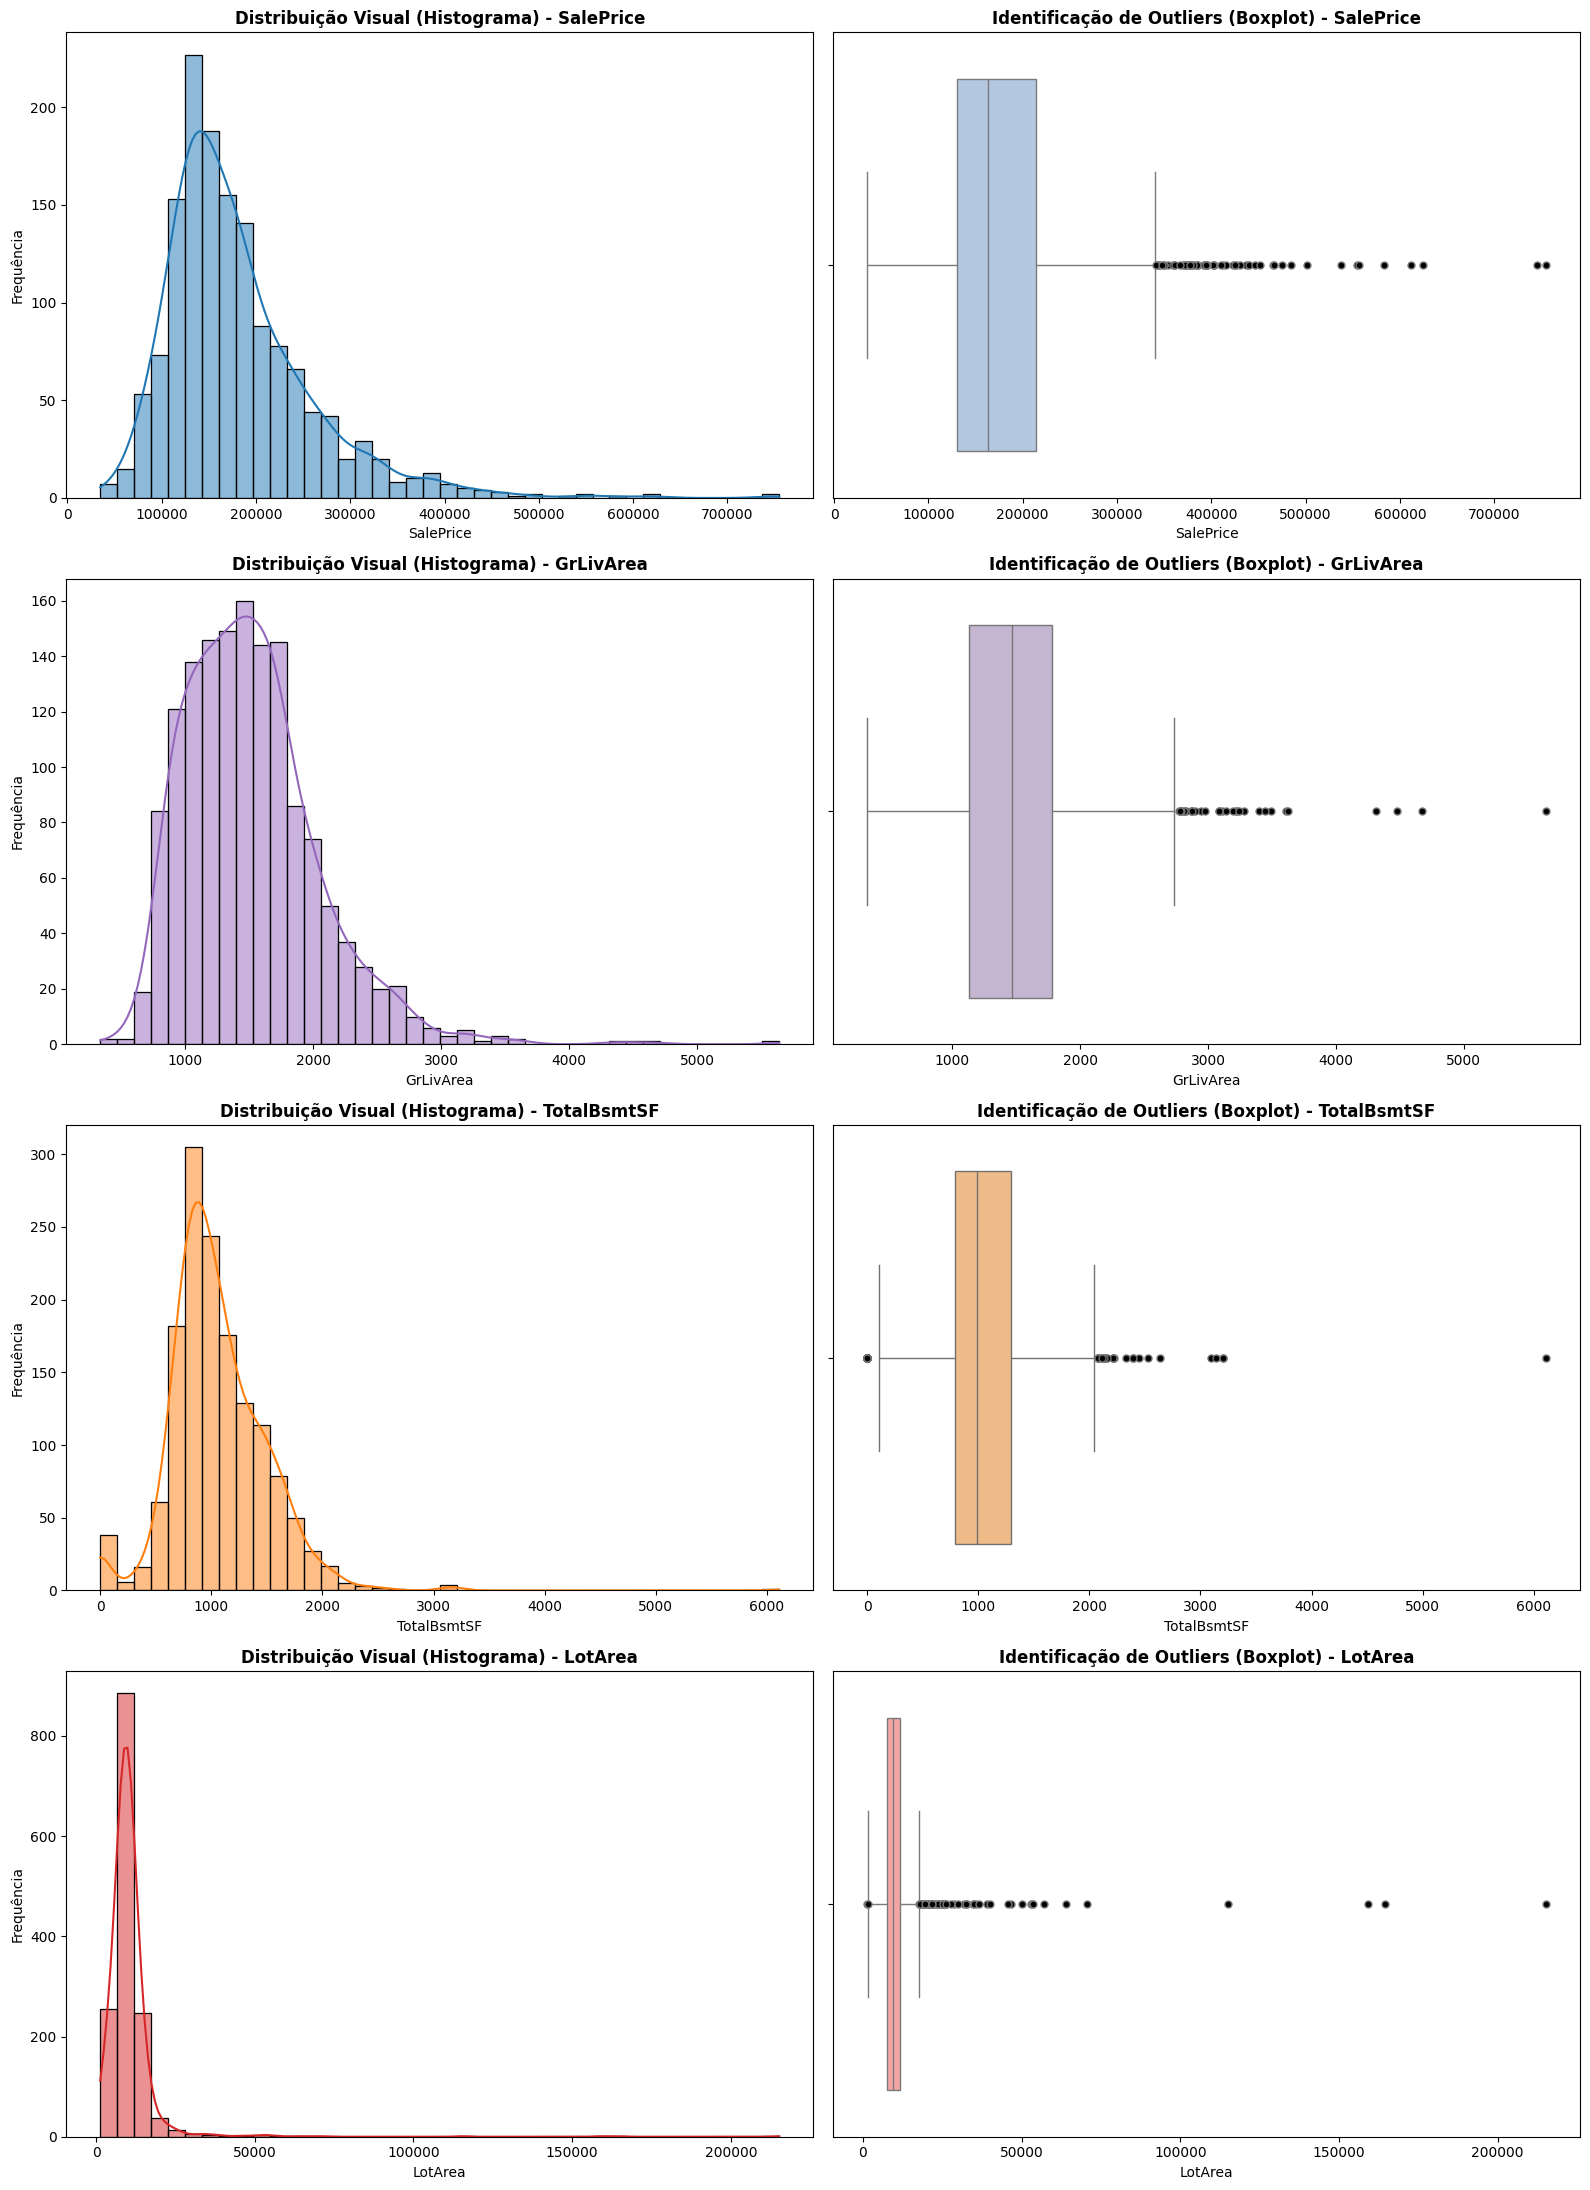

In [37]:
# --- DISTRIBUIÇÃO E OUTLIERS ---
fig, axes = plt.subplots(4, 2, figsize=(16, 22))

# Lista de variáveis críticas selecionadas na triagem estatística
colunas_chave = ['SalePrice', 'GrLivArea', 'TotalBsmtSF', 'LotArea']
cores_hist = ['#1f77b4', '#9467bd', '#ff7f0e', '#d62728']
cores_box = ['#aec7e8', '#c5b0d5', '#ffbb78', '#ff9896']

for i, col in enumerate(colunas_chave):
    # --- COLUNA 1: HISTOGRAMA (Formato da Distribuição) ---
    sns.histplot(data=houses, x=col, kde=True, ax=axes[i, 0], color=cores_hist[i], bins=40)
    axes[i, 0].set_title(f'Distribuição Visual (Histograma) - {col}', fontsize=12, fontweight='bold')
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Frequência')

    # --- COLUNA 2: BOXPLOT (Identificação de Outliers) ---
    # flierprops configura os outliers como bolinhas pretas limpas e destacadas
    sns.boxplot(
        data=houses,
        x=col,
        ax=axes[i, 1],
        color=cores_box[i],
        flierprops=dict(markerfacecolor='black', marker='o', markersize=5)
    )
    axes[i, 1].set_title(f'Identificação de Outliers (Boxplot) - {col}', fontsize=12, fontweight='bold')
    axes[i, 1].set_xlabel(col)

plt.tight_layout()
plt.show()

#### **Análise Univariada - Formato das Distribuições e Detecção de Outliers**

O painel visual acima cruza duas ferramentas fundamentais da análise univariada: os histogramas (com curvas de densidade KDE), que revelam o comportamento probabilístico dos dados, e os boxplots, focados na identificação geométrica de anomalias estatísticas. A análise concentrou-se no núcleo preditivo do dataset:

1.  **Preço de Venda (`SalePrice`):** A variável alvo demonstra uma curva assimétrica à direita. A maior densidade de transações imobiliárias ocorre entre \$129.975 e \$214.000 (faixa interquartil). O boxplot aponta uma quantidade expressiva de *outliers* superiores acima da marca dos \$340.000, evidenciando a presença de um segmento de alto luxo que puxa a média para cima da mediana.
2.  **Área Habitável (`GrLivArea`):** Como o tamanho do imóvel é o principal vetor de valor, a sua distribuição mimetiza a assimetria positiva do preço. A mediana estabelece-se em 1.464 sqft. No boxplot, destacam-se claramente dois *outliers* extremos que superam os 4.500 sqft. Estes imóveis específicos exigirão monitorização nas etapas seguintes, pois podem atuar como pontos de alta alavancagem.
3.  **Área Total do Porão (`TotalBsmtSF`):** O histograma exibe uma distribuição bimodal subtil. O pequeno pico isolado na linha do **0.00** comprova visualmente a existência de propriedades construídas sem porão. Fora essa particularidade, a distribuição central é estável, registando raros *outliers* que ultrapassam os 3.000 sqft.
4.  **Tamanho do Lote (`LotArea`):** É o caso mais severo de distorção de escala por *outliers*. O histograma aparece comprimido à esquerda porque a escala do eixo X precisa de acomodar terrenos rurais ou chácaras atípicas que chegam a 215.245 sqft, enquanto a mediana dos lotes urbanos residenciais é de apenas 9.478 sqft. O boxplot traduz essa discrepância com uma linha densa e contínua de pontos flutuantes além dos limites teóricos da distribuição.

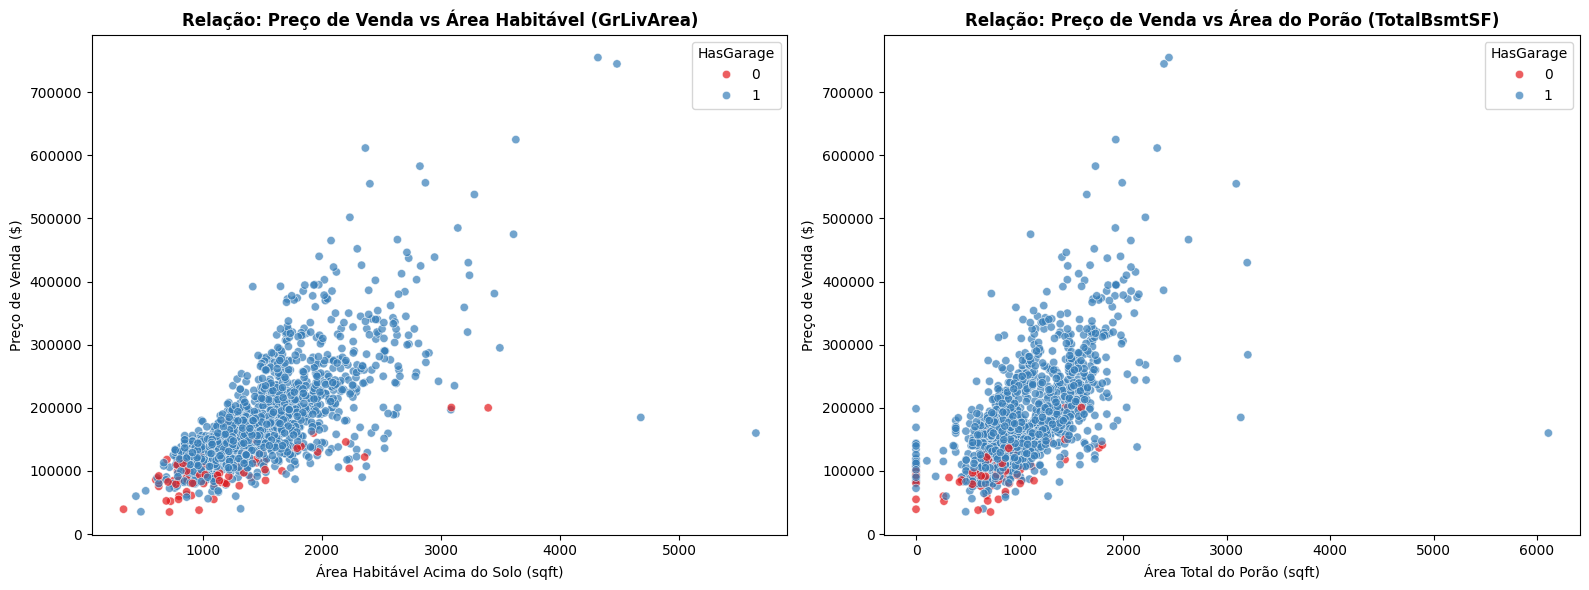

In [38]:
# --- PASSO 3: GRÁFICOS DE DISPERSÃO (ANÁLISE BIVARIADA) ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Preço de Venda vs Área Habitável (GrLivArea)
sns.scatterplot(
    data=houses,
    x='GrLivArea',
    y='SalePrice',
    hue='HasGarage',
    palette='Set1',
    alpha=0.7,
    ax=axes[0]
)
axes[0].set_title('Relação: Preço de Venda vs Área Habitável (GrLivArea)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Área Habitável Acima do Solo (sqft)')
axes[0].set_ylabel('Preço de Venda ($)')

# 2. Preço de Venda vs Área do Porão (TotalBsmtSF)
sns.scatterplot(
    data=houses,
    x='TotalBsmtSF',
    y='SalePrice',
    hue='HasGarage',
    palette='Set1',
    alpha=0.7,
    ax=axes[1]
)
axes[1].set_title('Relação: Preço de Venda vs Área do Porão (TotalBsmtSF)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Área Total do Porão (sqft)')
axes[1].set_ylabel('Preço de Venda ($)')

plt.tight_layout()
plt.show()

#### **Análise Bivariada - Relações Lineares e Deteção de Outliers Bivariados**

Para cumprir a diretriz de explorar o impacto das variáveis contínuas sobre o preço de venda (`SalePrice`), cruzámos a variável alvo com os dois preditores numéricos de dimensão física mais expressivos do dataset: a Área Habitável (`GrLivArea`) e a Área Total do Porão (`TotalBsmtSF`). Adicionalmente, mapeámos a variável indicadora `HasGarage` na coloração dos pontos para avaliar o impacto da ausência de garagem no comportamento dos dados.

##### **1. Tendência Linear e Força da Relação**
* **Área Habitável (`GrLivArea`):** O gráfico revela uma inclinação positiva clara e robusta. À medida que a metragem quadrada acima do solo aumenta, o preço de venda responde de forma diretamente proporcional. Este comportamento visual reflete graficamente o elevado coeficiente de correlação linear que estas variáveis partilham, consolidando a área habitável como o principal motor de valorização imobiliária no mercado de Ames.
* **Área do Porão (`TotalBsmtSF`):** Exibe uma tendência linear positiva semelhante, indicando que a estrutura subterrânea agrega valor económico direto à propriedade. Observa-se um alinhamento vertical de pontos localizados exatamente na marca de **0.00** no eixo X (identificados maioritariamente na cor vermelha, correspondente à ausência de garagem). Este padrão comprova que imóveis desprovidos de porão e garagem sofrem uma severa penalização de mercado, ficando confinados às faixas de preço mais baixas.

##### **2. Identificação de Outliers Bivariados (Anomalias de Relação)**
A análise de dispersão permitiu detetar anomalias que passavam despercebidas na análise univariada isolada, conhecidas como *outliers* bivariados:
* **O Fenômeno do Alto Tamanho e Baixo Preço:** No gráfico de `GrLivArea`, observam-se duas propriedades extremas no canto inferior direito (com mais de 4.500 e 5.500 pés quadrados de área) que foram vendidas por valores abaixo de \$200.000. Estatisticamente, residências deste porte deveriam registar valores substancialmente maiores. Estes pontos exigirão atenção redobrada no pré-processamento para a Etapa 2, pois propriedades massivas vendidas a preços desproporcionalmente baixos quebram a hipótese de linearidade e podem distorcer severamente o treino dos modelos de regressão.

##### **3. Validação Visual da Variável Indicadora (`HasGarage`)**
A inclusão do parâmetro de coloração validou a relevância da nova variável criada. Os pontos vermelhos (casas sem garagem) encontram-se agrupados na base de ambos os gráficos, demonstrando que a ausência deste recurso atua como um teto limitador para o valor de mercado, justificando a utilidade da variável booleana para os futuros modelos preditivos.

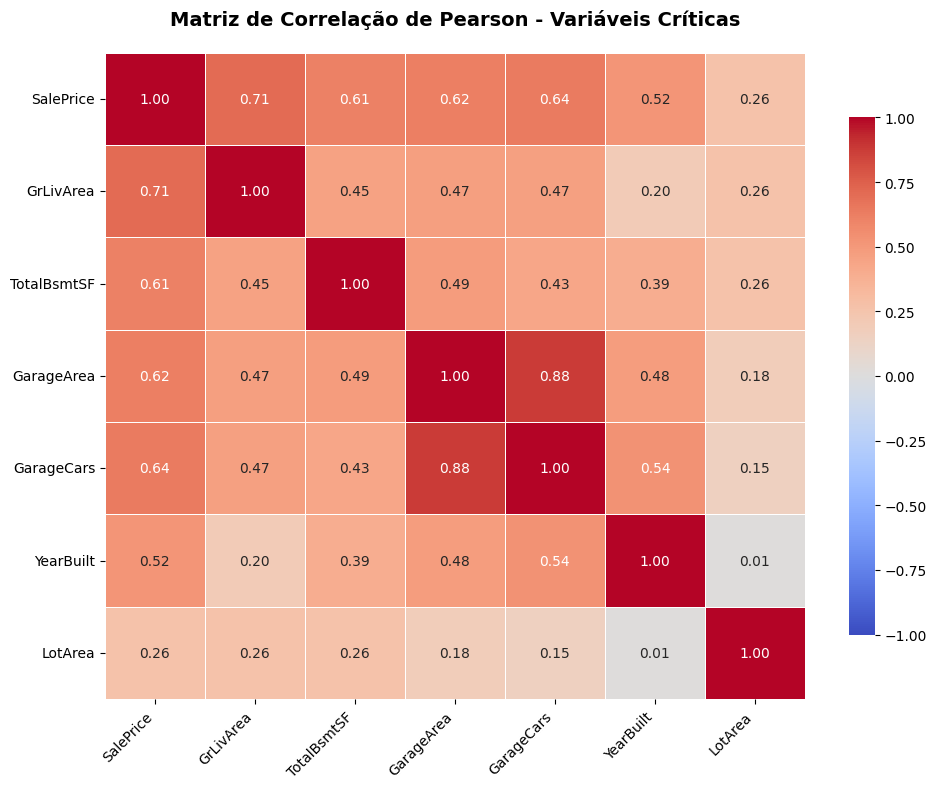

In [39]:
# --- PASSO 4: MATRIZ DE CORRELAÇÃO (HEATMAP) ---

# Seleção das variáveis preditoras mais expressivas + a variável alvo
colunas_correlacao = ['SalePrice', 'GrLivArea', 'TotalBsmtSF', 'GarageArea', 'GarageCars', 'YearBuilt', 'LotArea']

# Calcula a matriz de correlação de Pearson
matriz_corr = houses[colunas_correlacao].corr()

# Configuração da figura do matplotlib
plt.figure(figsize=(10, 8))

# Cria o mapa de calor (Heatmap)
# coolwarm gera um gradiente intuitivo: azul para negativo, branco para neutro e vermelho para positivo
sns.heatmap(
    matriz_corr,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"shrink": .8}
)

plt.title('Matriz de Correlação de Pearson - Variáveis Críticas', fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

#### **Passo 4: Análise de Associação Linear (Matriz de Correlação de Pearson)**

Para quantificar a intensidade e a direção das relações lineares entre as variáveis contínuas e o valor de mercado, gerámos uma Matriz de Correlação de Pearson filtrada para os preditores de maior impacto. O coeficiente varia de -1.00 (correlação negativa perfeita) a 1.00 (correlação positiva perfeita), servindo como bússola estatística para a seleção de atributos (*feature selection*).

##### **1. Preditores de Forte Impacto Linear no Preço (`SalePrice`)**
* **Área Habitável (`GrLivArea`):** Confirma-se como a variável de maior associação linear com o preço de venda, registando um coeficiente expressivo de **0.71**. Isto valida matematicamente o comportamento observado nos gráficos de dispersão: a expansão da área útil acima do solo é o fator individual que mais impulsiona o valor do imóvel.
* **Infraestrutura da Garagem (`GarageCars` e `GarageArea`):** Apresentam forte correlação com a variável alvo (na faixa de **0.62** a **0.64**). Estes valores indicam que a capacidade física de armazenamento de veículos é um forte indicador socioeconómico do padrão da residência em Ames.
* **Área do Porão (`TotalBsmtSF`):** Exibe uma correlação de **0.61**, consolidando a importância das áreas de fundação e subsolo na composição da precificação final.

##### **2. Identificação de Multicolinearidade (Aviso Estratégico para Modelagem)**
Um insight avançado fornecido pelo Heatmap é o diagnóstico de **multicolinearidade** (quando duas variáveis preditoras são altamente correlacionadas entre si):
* **O caso da Garagem:** A correlação entre `GarageCars` (vagas) e `GarageArea` (área em sqft) atinge impressionantes **0.88**.
* **O caso da Área:** A correlação entre o porão (`TotalBsmtSF`) e o primeiro andar (`1stFlrSF`) costuma ser igualmente elevada por razões de simetria construtiva.

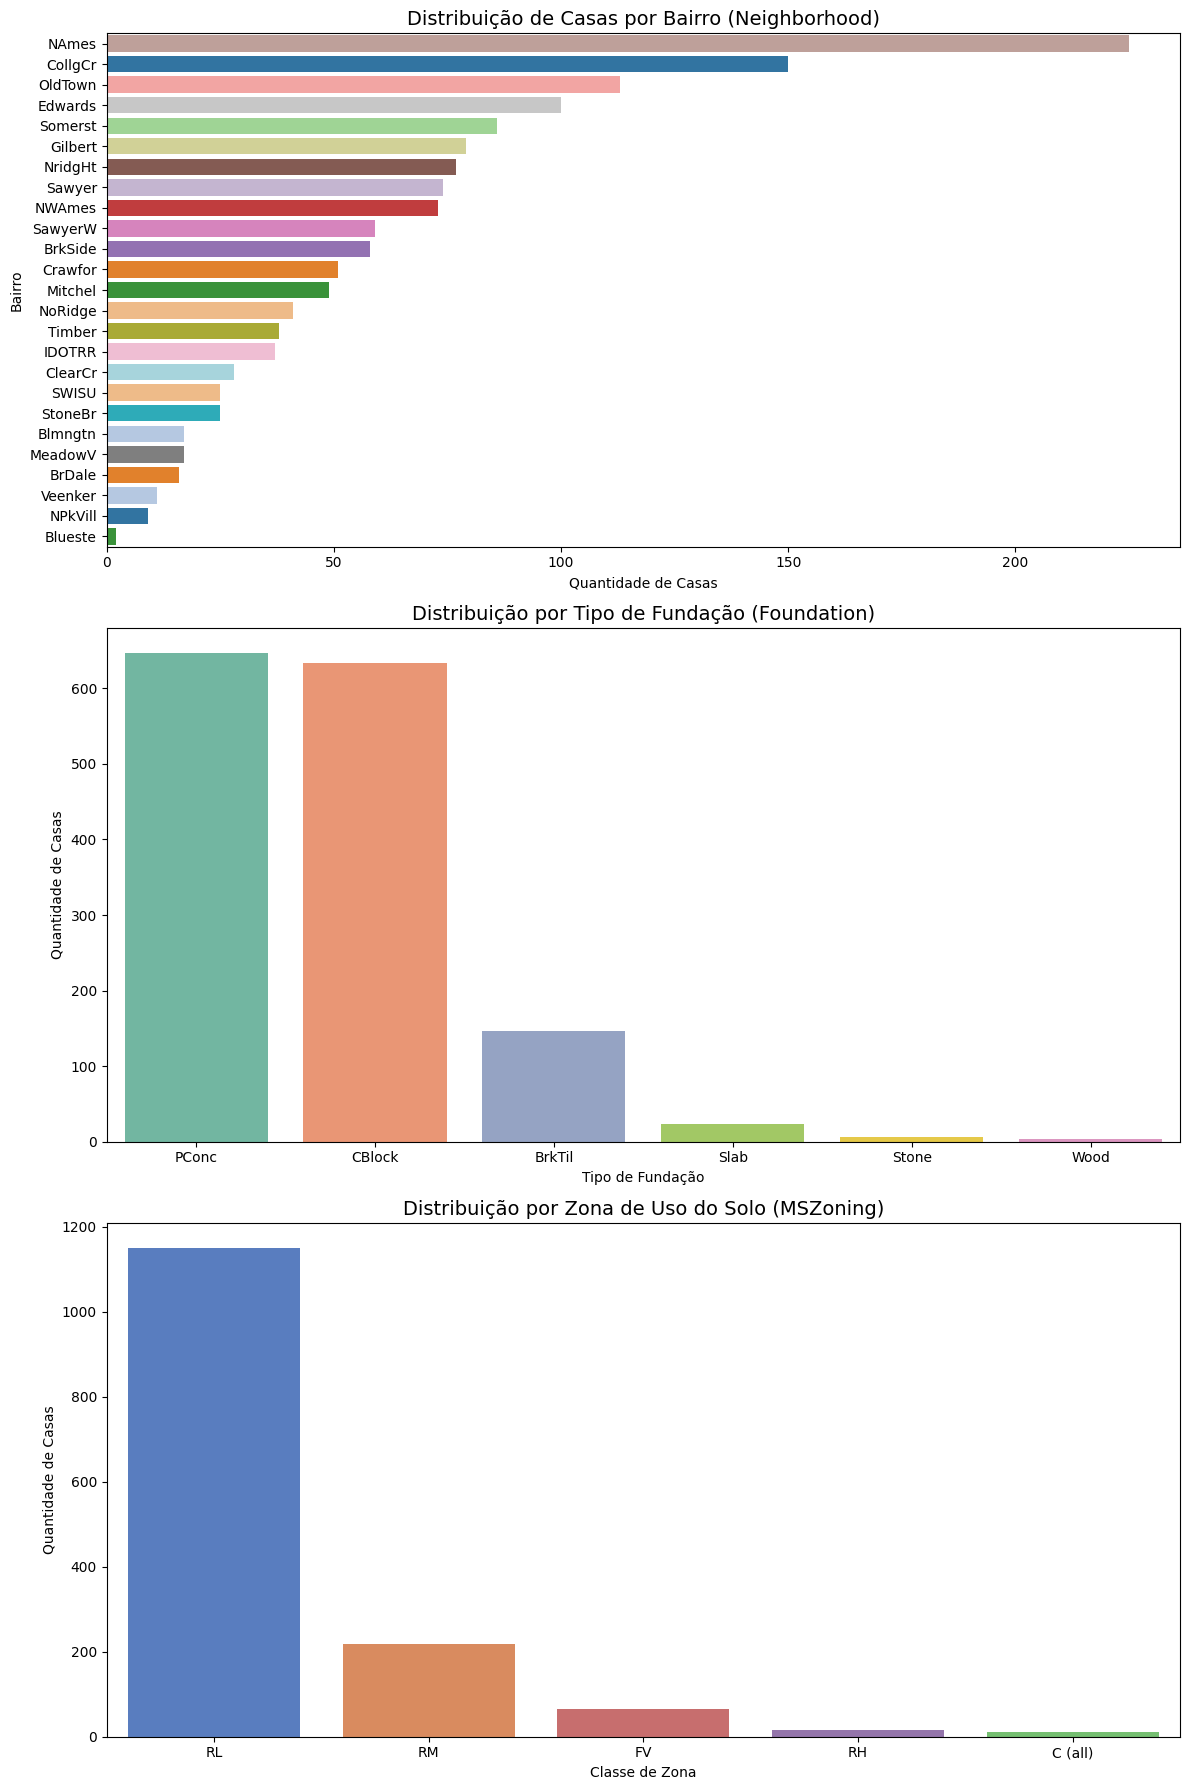

In [40]:
# Objetivo: Plotar a frequência das variáveis categóricas corrigindo paletas e avisos do Seaborn
fig, axes = plt.subplots(3, 1, figsize=(12, 18))

# 1. Neighborhood (Usando 'tab20' para cobrir a grande variedade de bairros)
sns.countplot(
    y=houses['Neighborhood'],
    order=houses['Neighborhood'].value_counts().index,
    ax=axes[0],
    hue=houses['Neighborhood'],
    legend=False,
    palette='tab20'
)
axes[0].set_title('Distribuição de Casas por Bairro (Neighborhood)', fontsize=14)
axes[0].set_xlabel('Quantidade de Casas')
axes[0].set_ylabel('Bairro')

# 2. Foundation (Substituído o erro por 'Set2')
sns.countplot(
    x=houses['Foundation'],
    order=houses['Foundation'].value_counts().index,
    ax=axes[1],
    hue=houses['Foundation'],
    legend=False,
    palette='Set2'
)
axes[1].set_title('Distribuição por Tipo de Fundação (Foundation)', fontsize=14)
axes[1].set_xlabel('Tipo de Fundação')
axes[1].set_ylabel('Quantidade de Casas')

# 3. MSZoning (Ajustado para 'muted')
sns.countplot(
    x=houses['MSZoning'],
    order=houses['MSZoning'].value_counts().index,
    ax=axes[2],
    hue=houses['MSZoning'],
    legend=False,
    palette='muted'
)
axes[2].set_title('Distribuição por Zona de Uso do Solo (MSZoning)', fontsize=14)
axes[2].set_xlabel('Classe de Zona')
axes[2].set_ylabel('Quantidade de Casas')

plt.tight_layout()
plt.show()

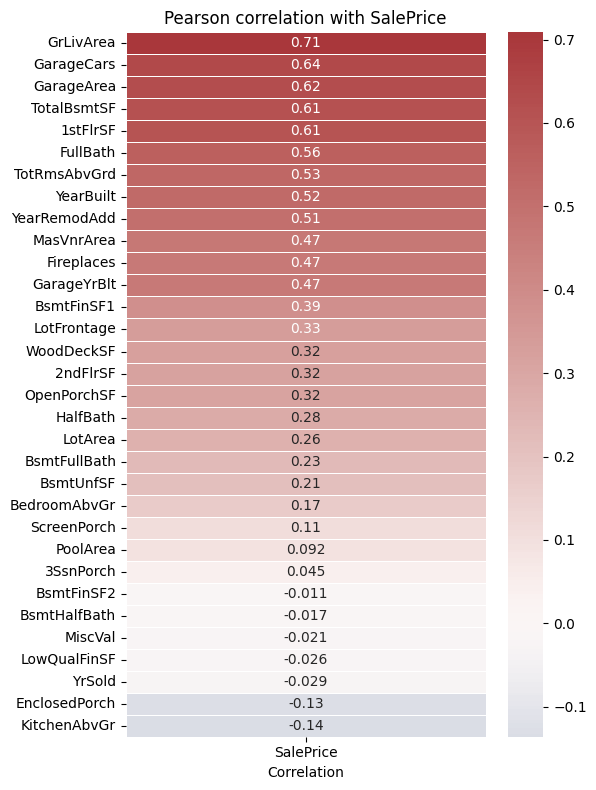

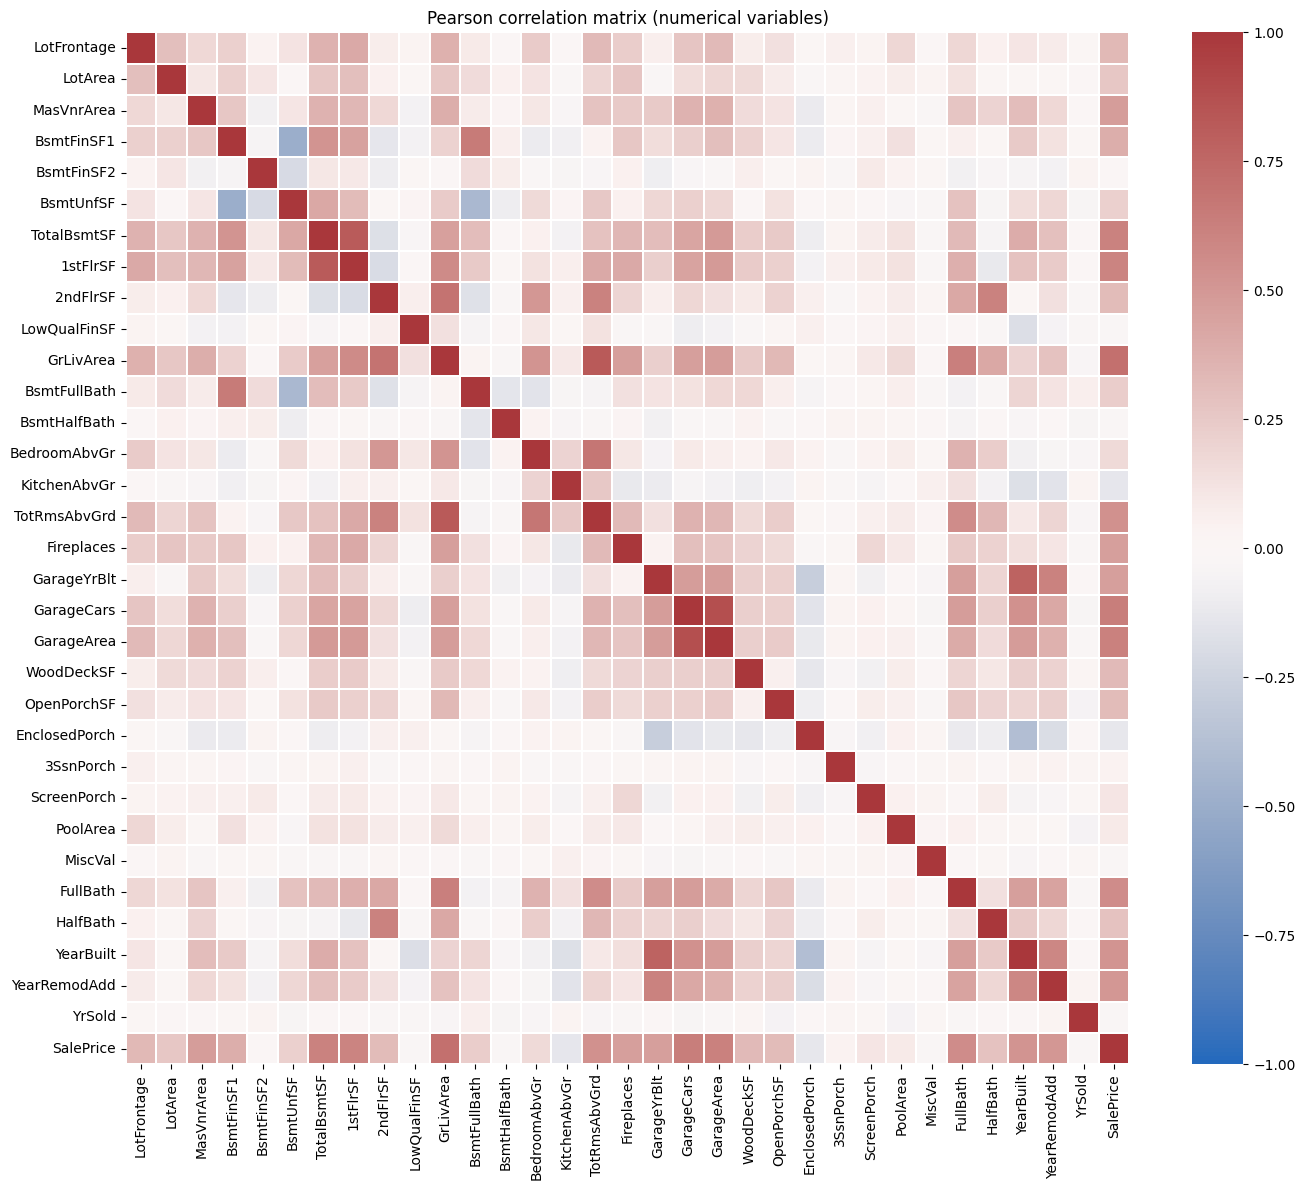

In [41]:
# Heatmaps: Pearson de SalePrice e variáveis numéricas

cols = numerical_cols.copy()
if 'SalePrice' not in cols:
    cols = cols + ['SalePrice']

# Pearson correlation matrix
corr_matrix = houses[cols].corr(method='pearson')

corr_with_target = corr_matrix['SalePrice'].drop('SalePrice')
corr_with_target = corr_with_target.sort_values(ascending=False)
plt.figure(figsize=(6, max(4, len(corr_with_target)*0.25)))
sns.heatmap(corr_with_target.to_frame(), annot=True, cmap='vlag', center=0, linewidths=0.5)
plt.title('Pearson correlation with SalePrice')
plt.xlabel('Correlation')
plt.tight_layout()
plt.show()

# Heatmap de correlação entre variáveis numéricas
plt.figure(figsize=(14,12))
sns.heatmap(corr_matrix, cmap='vlag', center=0, vmax=1, vmin=-1, linewidths=0.25)
plt.title('Pearson correlation matrix (numerical variables)')
plt.tight_layout()
plt.show()

## Análise de Variáveis Categóricas

Selecionamos variáveis categóricas com maior potencial explicativo para `SalePrice`, priorizando localização, estilo da casa e contexto da venda: `Neighborhood`, `HouseStyle`, `MSZoning`, `SaleType`, `SaleCondition`, `BldgType` e `CentralAir`.

Nesta seção, os gráficos de distribuição mostram a frequência de cada categoria, enquanto os boxplots ajudam a comparar a distribuição de `SalePrice` entre os grupos e a identificar variáveis com maior poder discriminativo para a etapa de modelagem.

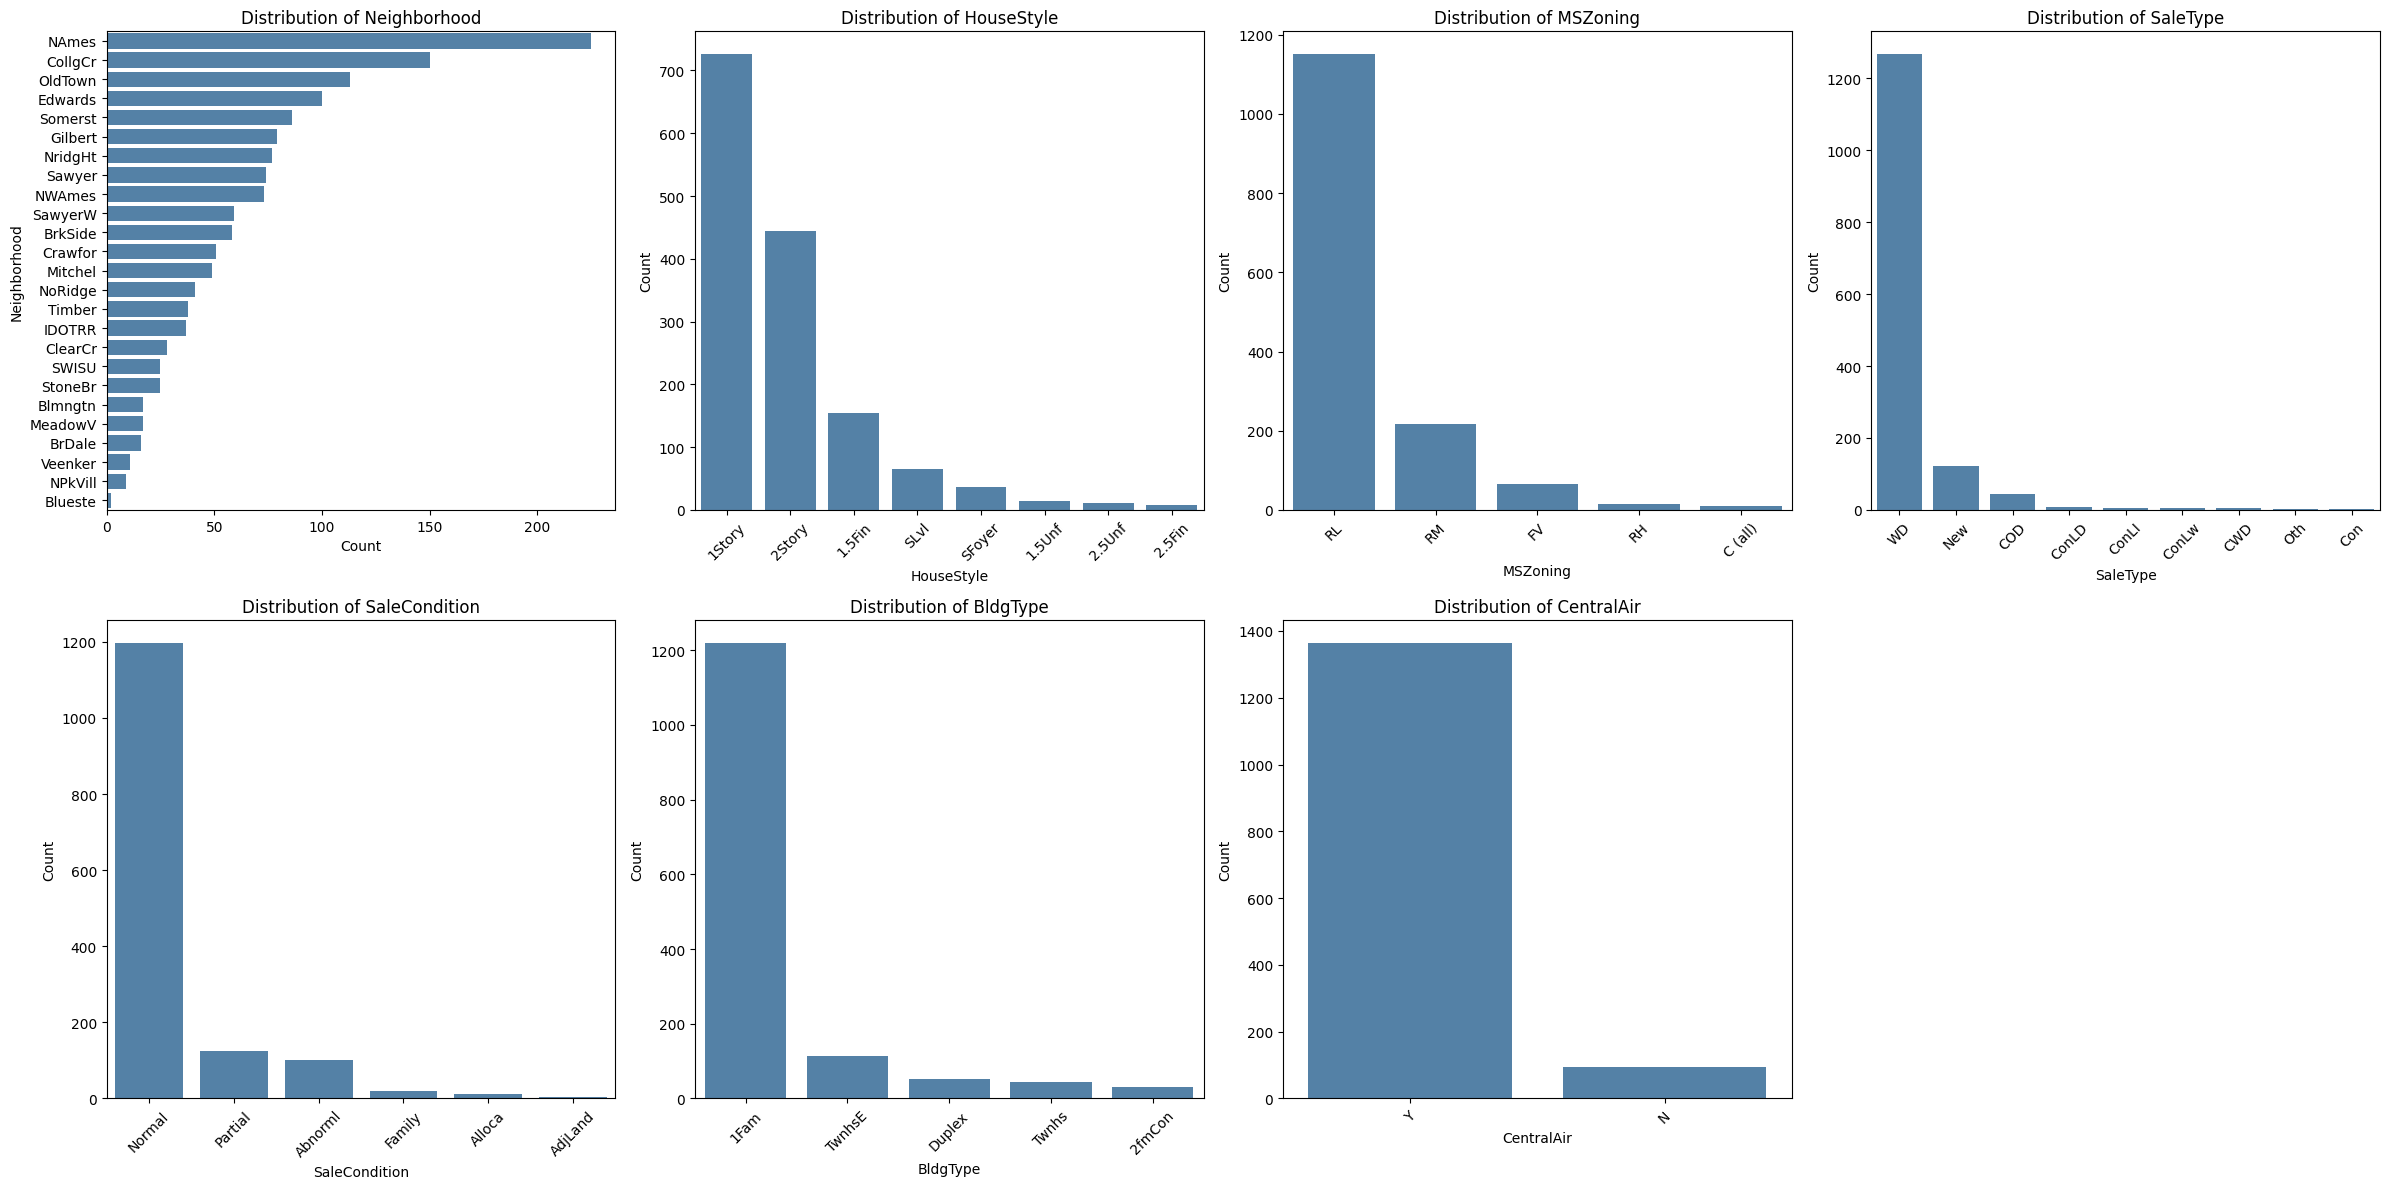

In [42]:
# Objetivo: visualizar a frequência das variáveis categóricas mais relevantes
import matplotlib.pyplot as plt
import seaborn as sns

categorical_focus_vars = [
    'Neighborhood', 'HouseStyle', 'MSZoning', 'SaleType',
    'SaleCondition', 'BldgType', 'CentralAir'
 ]

fig, axes = plt.subplots(2, 4, figsize=(24, 12))
axes = axes.flatten()

for idx, var in enumerate(categorical_focus_vars):
    order = houses[var].value_counts().index
    if var == 'Neighborhood':
        sns.countplot(data=houses, y=var, order=order, ax=axes[idx], color='steelblue')
        axes[idx].set_xlabel('Count')
        axes[idx].set_ylabel(var)
    else:
        sns.countplot(data=houses, x=var, order=order, ax=axes[idx], color='steelblue')
        axes[idx].set_xlabel(var)
        axes[idx].set_ylabel('Count')
        axes[idx].tick_params(axis='x', rotation=45)
    axes[idx].set_title(f'Distribution of {var}')

for idx in range(len(categorical_focus_vars), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()


/tmp/ipykernel_7087/2080718747.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Neighborhood', y='SalePrice', data=houses, order=order, palette='vlag')


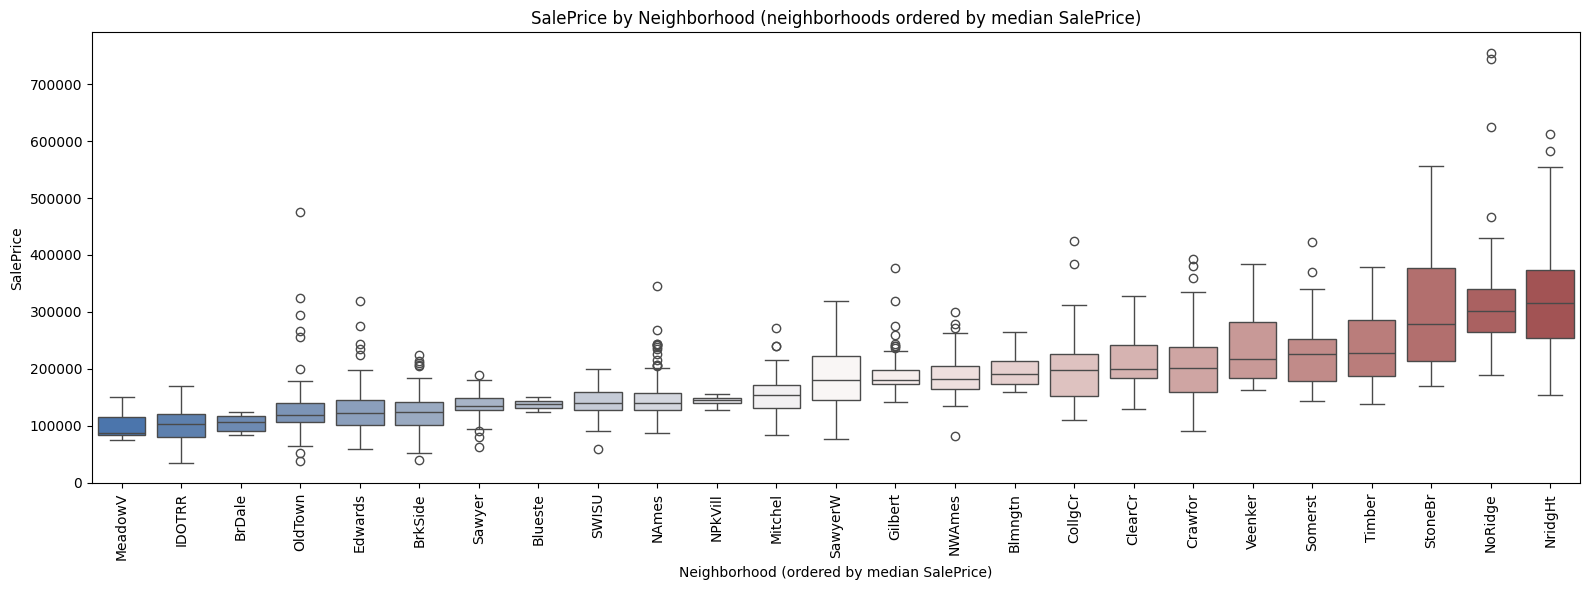

In [43]:
# Boxplots de Saleprice para cada Neighborhood ordenados pela mediana de SalePrice

neigh_medians = houses.groupby('Neighborhood')['SalePrice'].median().sort_values()
order = neigh_medians.index

plt.figure(figsize=(16, 6))
sns.boxplot(x='Neighborhood', y='SalePrice', data=houses, order=order, palette='vlag')
plt.xticks(rotation=90)
plt.title('SalePrice by Neighborhood (neighborhoods ordered by median SalePrice)')
plt.xlabel('Neighborhood (ordered by median SalePrice)')
plt.ylabel('SalePrice')
plt.tight_layout()
plt.show()

**O que fazer com bairros com poucas instâncias?**
Como pode ser visto no boxplot gerado para `SalePrice` em cada um dos bairros do dataset, assim como no gráfico de barras da variável `Neighborhood`, alguns bairros possuem poucas instâncias. Para as próximas etapas, é importante decidir o que será realizado com tais grupos raros. Uma possibilidade seria agrupar bairros com poucas instâncias numa categoria `Outros`.

Bairros com menos de 30 instâncias
- ``Blueste``
- ``NPkVill``
- ``Veenker``
- ``BrDale``
- ``MeadowV``
- ``Blmngtn``
- ``StoneBr``
- ``SWISU``
- ``ClearCr``

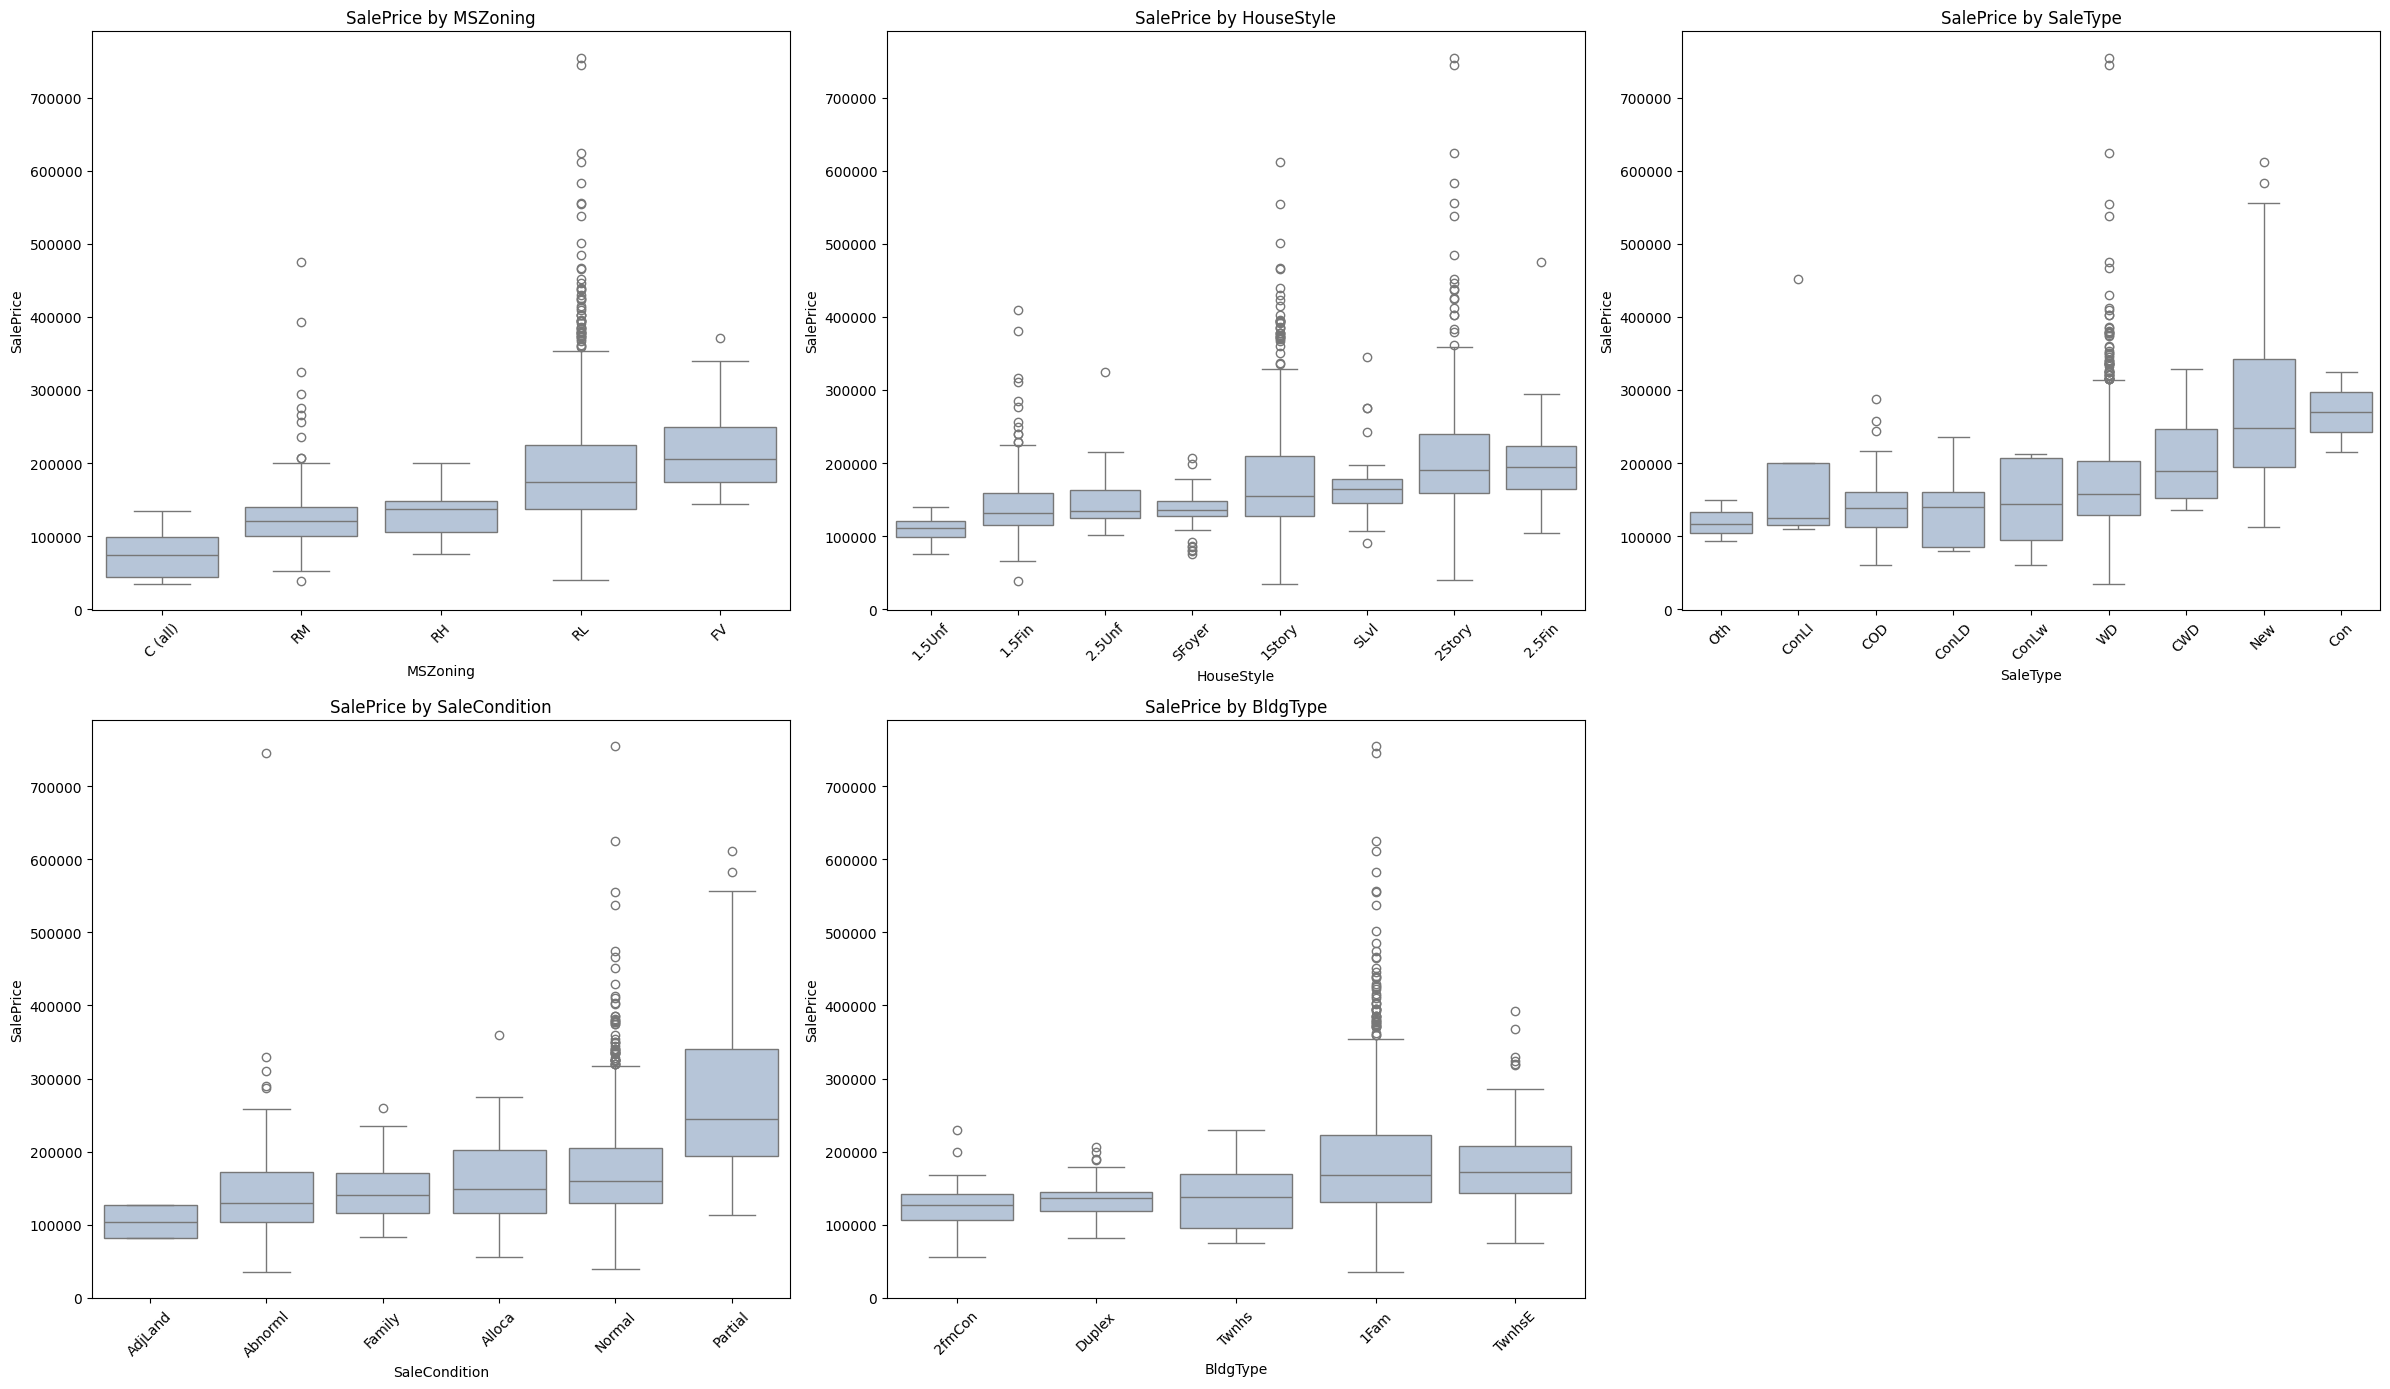

In [44]:
# Objetivo: comparar SalePrice entre categorias relevantes usando boxplots

boxplot_vars = ['MSZoning', 'HouseStyle', 'SaleType', 'SaleCondition', 'BldgType']

fig, axes = plt.subplots(2, 3, figsize=(24, 14))
axes = axes.flatten()

for idx, var in enumerate(boxplot_vars):
    order = houses.groupby(var)['SalePrice'].median().sort_values().index
    sns.boxplot(data=houses, x=var, y='SalePrice', order=order, ax=axes[idx], color='lightsteelblue')
    axes[idx].set_title(f'SalePrice by {var}')
    axes[idx].set_xlabel(var)
    axes[idx].set_ylabel('SalePrice')
    axes[idx].tick_params(axis='x', rotation=45)

for idx in range(len(boxplot_vars), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

## Análise de Variáveis Ordinais:

Lista das variáveis ordinais identificadas:
* **LotShape**: Forma geral da propriedade
* **LandSlope**: Declive da propriedade
* **OverallQual**: Material geral e acabamento
* **OverallCond**: Estado geral da casa
* **ExterQual**: Qualidade do material externo
* **ExterCond**: Condição do material externo
* **BsmtQual**: Altura do porão
* **BsmtCond**: Estado geral do porão
* **BsmtExposure**: Exposição de muros do porão
* **BsmtFinType1**: Acabamento do porão (Tipo 1)
* **BsmtFinType2**: Acabamento do porão (Tipo 2)
* **HeatingQC**: Qualidade do aquecimento
* **KitchenQual**: Qualidade da cozinha
* **Functional**: Funcionalidade geral da casa
* **FireplaceQu**: Qualidade da lareira
* **GarageFinish**: Acabamento interno da garagem
* **GarageQual**: Qualidade da garagem
* **GarageCond**: Condições da garagem
* **PavedDrive**: Entrada pavimentada
* **PoolQC**: Qualidade da piscina

Aqui, dentre as variáveis ordinais identificadas no dataset, selecionamos para análise as principais relacionadas à condição e à qualidade de diversos aspectos das casas:

``OverallQual``
``OverallCond``
``ExterQual``
``ExterCond``
``BsmtQual``
``BsmtCond``
``KitchenQual``
``GarageQual``
``GarageCond``

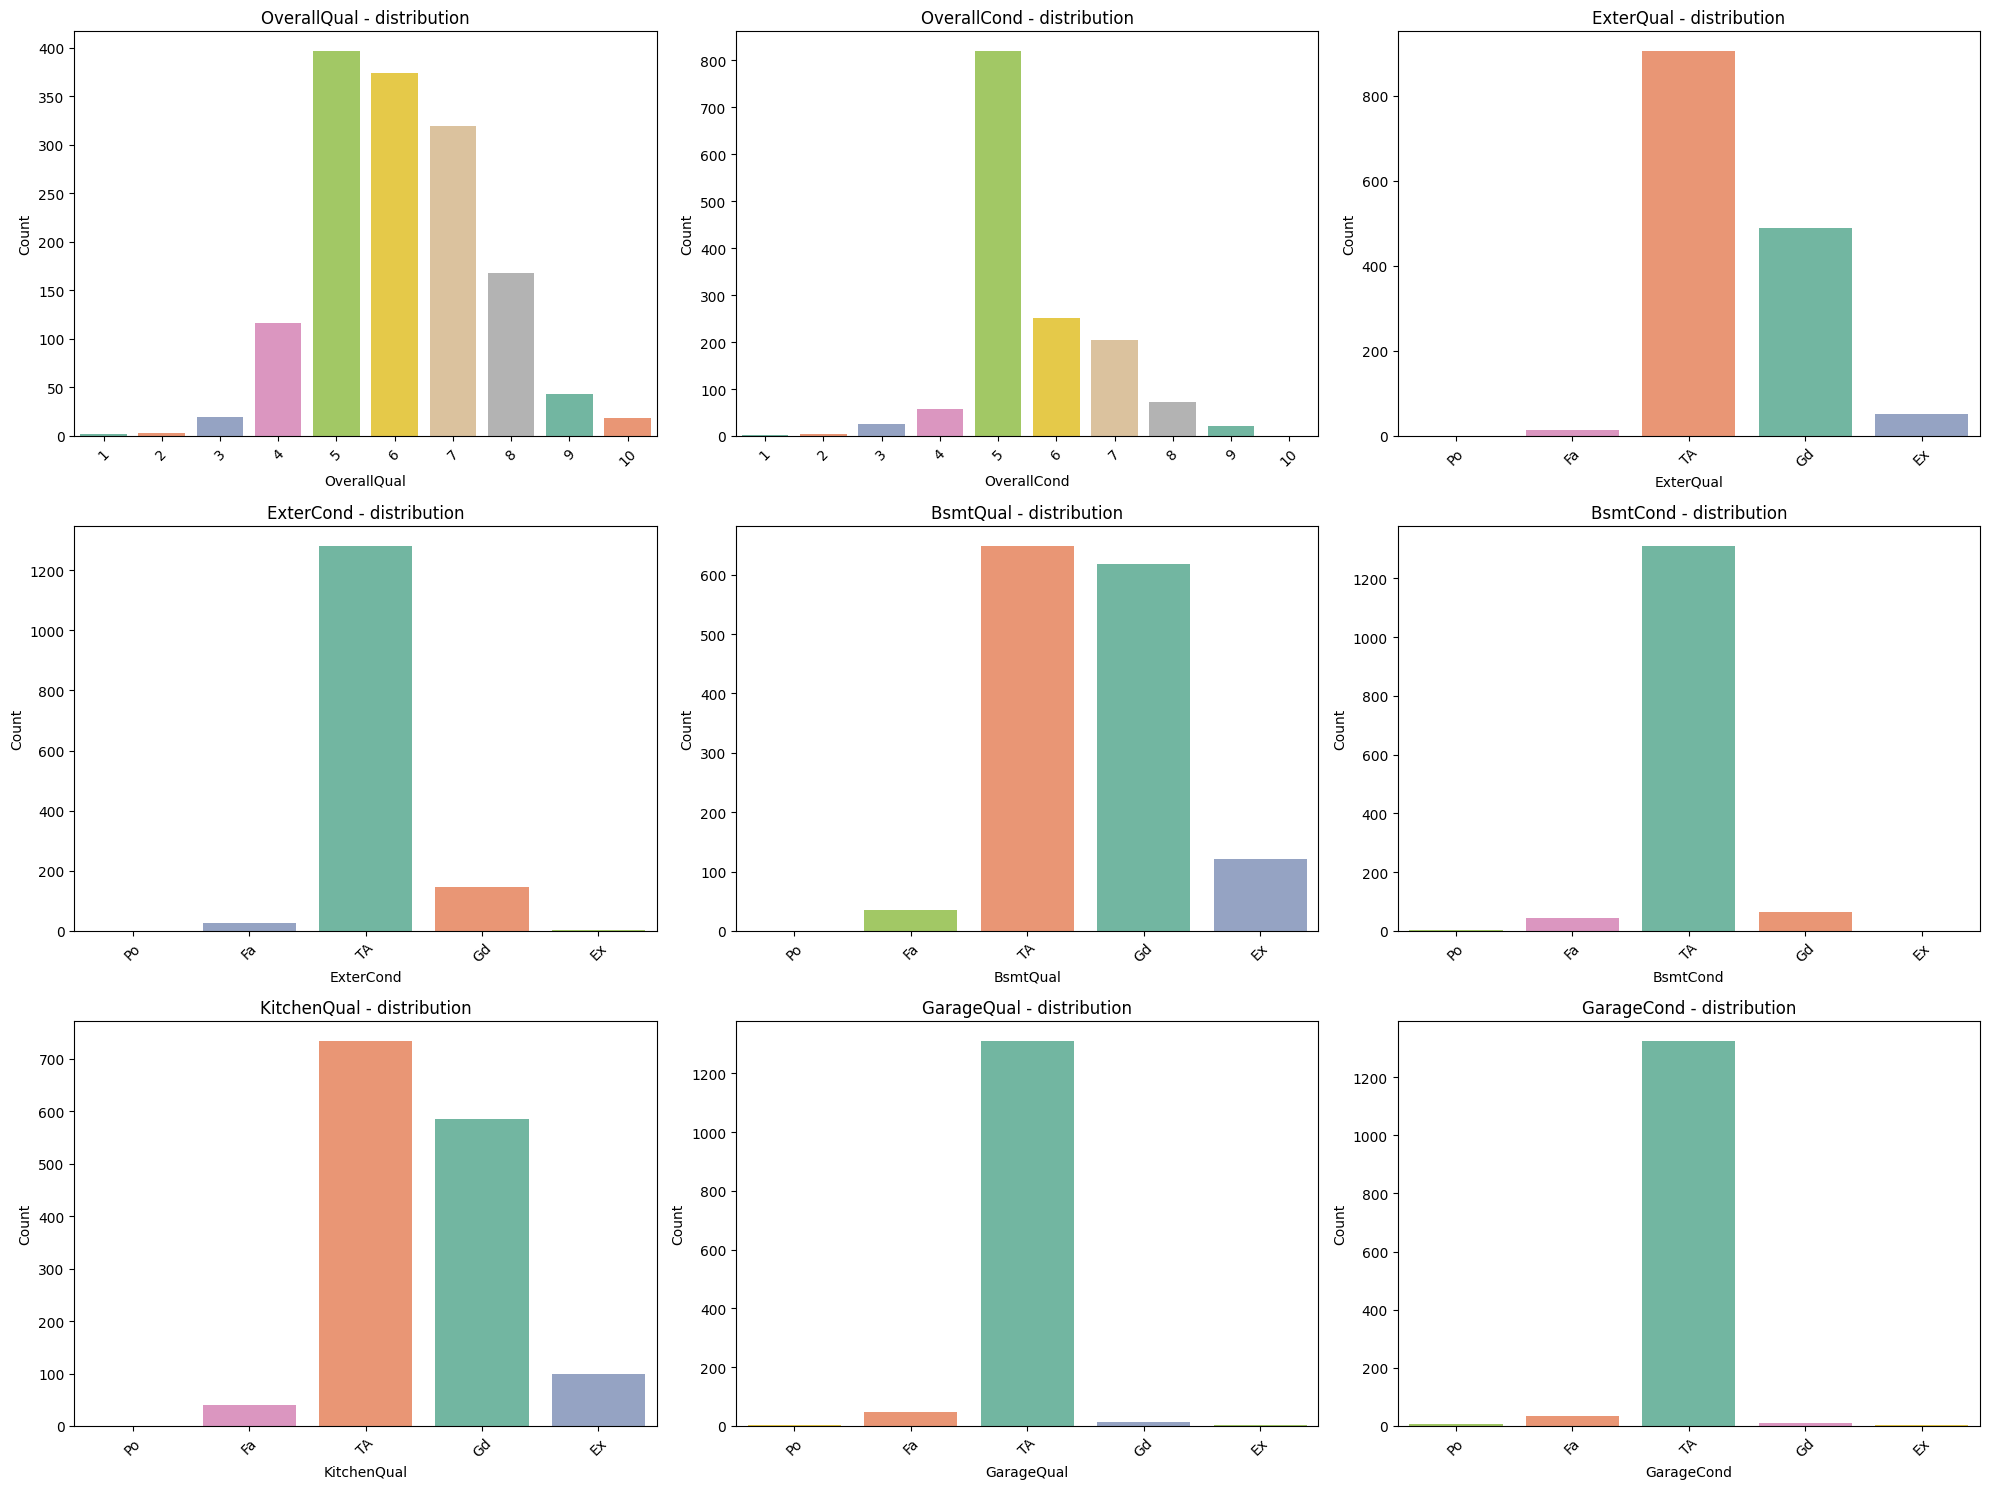

In [45]:
# Objetivo: criar gráficos de barras para as variáveis ordinais destacadas

ordinal_order_map = {
    'OverallQual': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'OverallCond': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'ExterQual': ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'ExterCond': ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'BsmtQual': ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'BsmtCond': ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'KitchenQual': ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'GarageQual': ['Po', 'Fa', 'TA', 'Gd', 'Ex'],
    'GarageCond': ['Po', 'Fa', 'TA', 'Gd', 'Ex']
}

ordinal_variables = list(ordinal_order_map.keys())

cols = 3
rows = math.ceil(len(ordinal_variables) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(20, 5 * rows))
axes = axes.flatten()

for idx, var in enumerate(ordinal_variables):
    order = ordinal_order_map[var]
    sns.countplot(data=houses, x=var, order=order, ax=axes[idx], palette='Set2', hue=var, legend=False)
    axes[idx].set_title(f'{var} - distribution')
    axes[idx].set_xlabel(var)
    axes[idx].set_ylabel('Count')
    axes[idx].tick_params(axis='x', rotation=45)

for idx in range(len(ordinal_variables), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

**Nota:** em algumas variáveis como ``GarageCond``, ``GarageQual``, ``BsmtCond`` e ``ExterCond``, vemos que a variância é muito baixa e a maior parte das casas se concentra em apenas um dos valores, o que pode tornar a variável pouco informativa para a análise de preços.

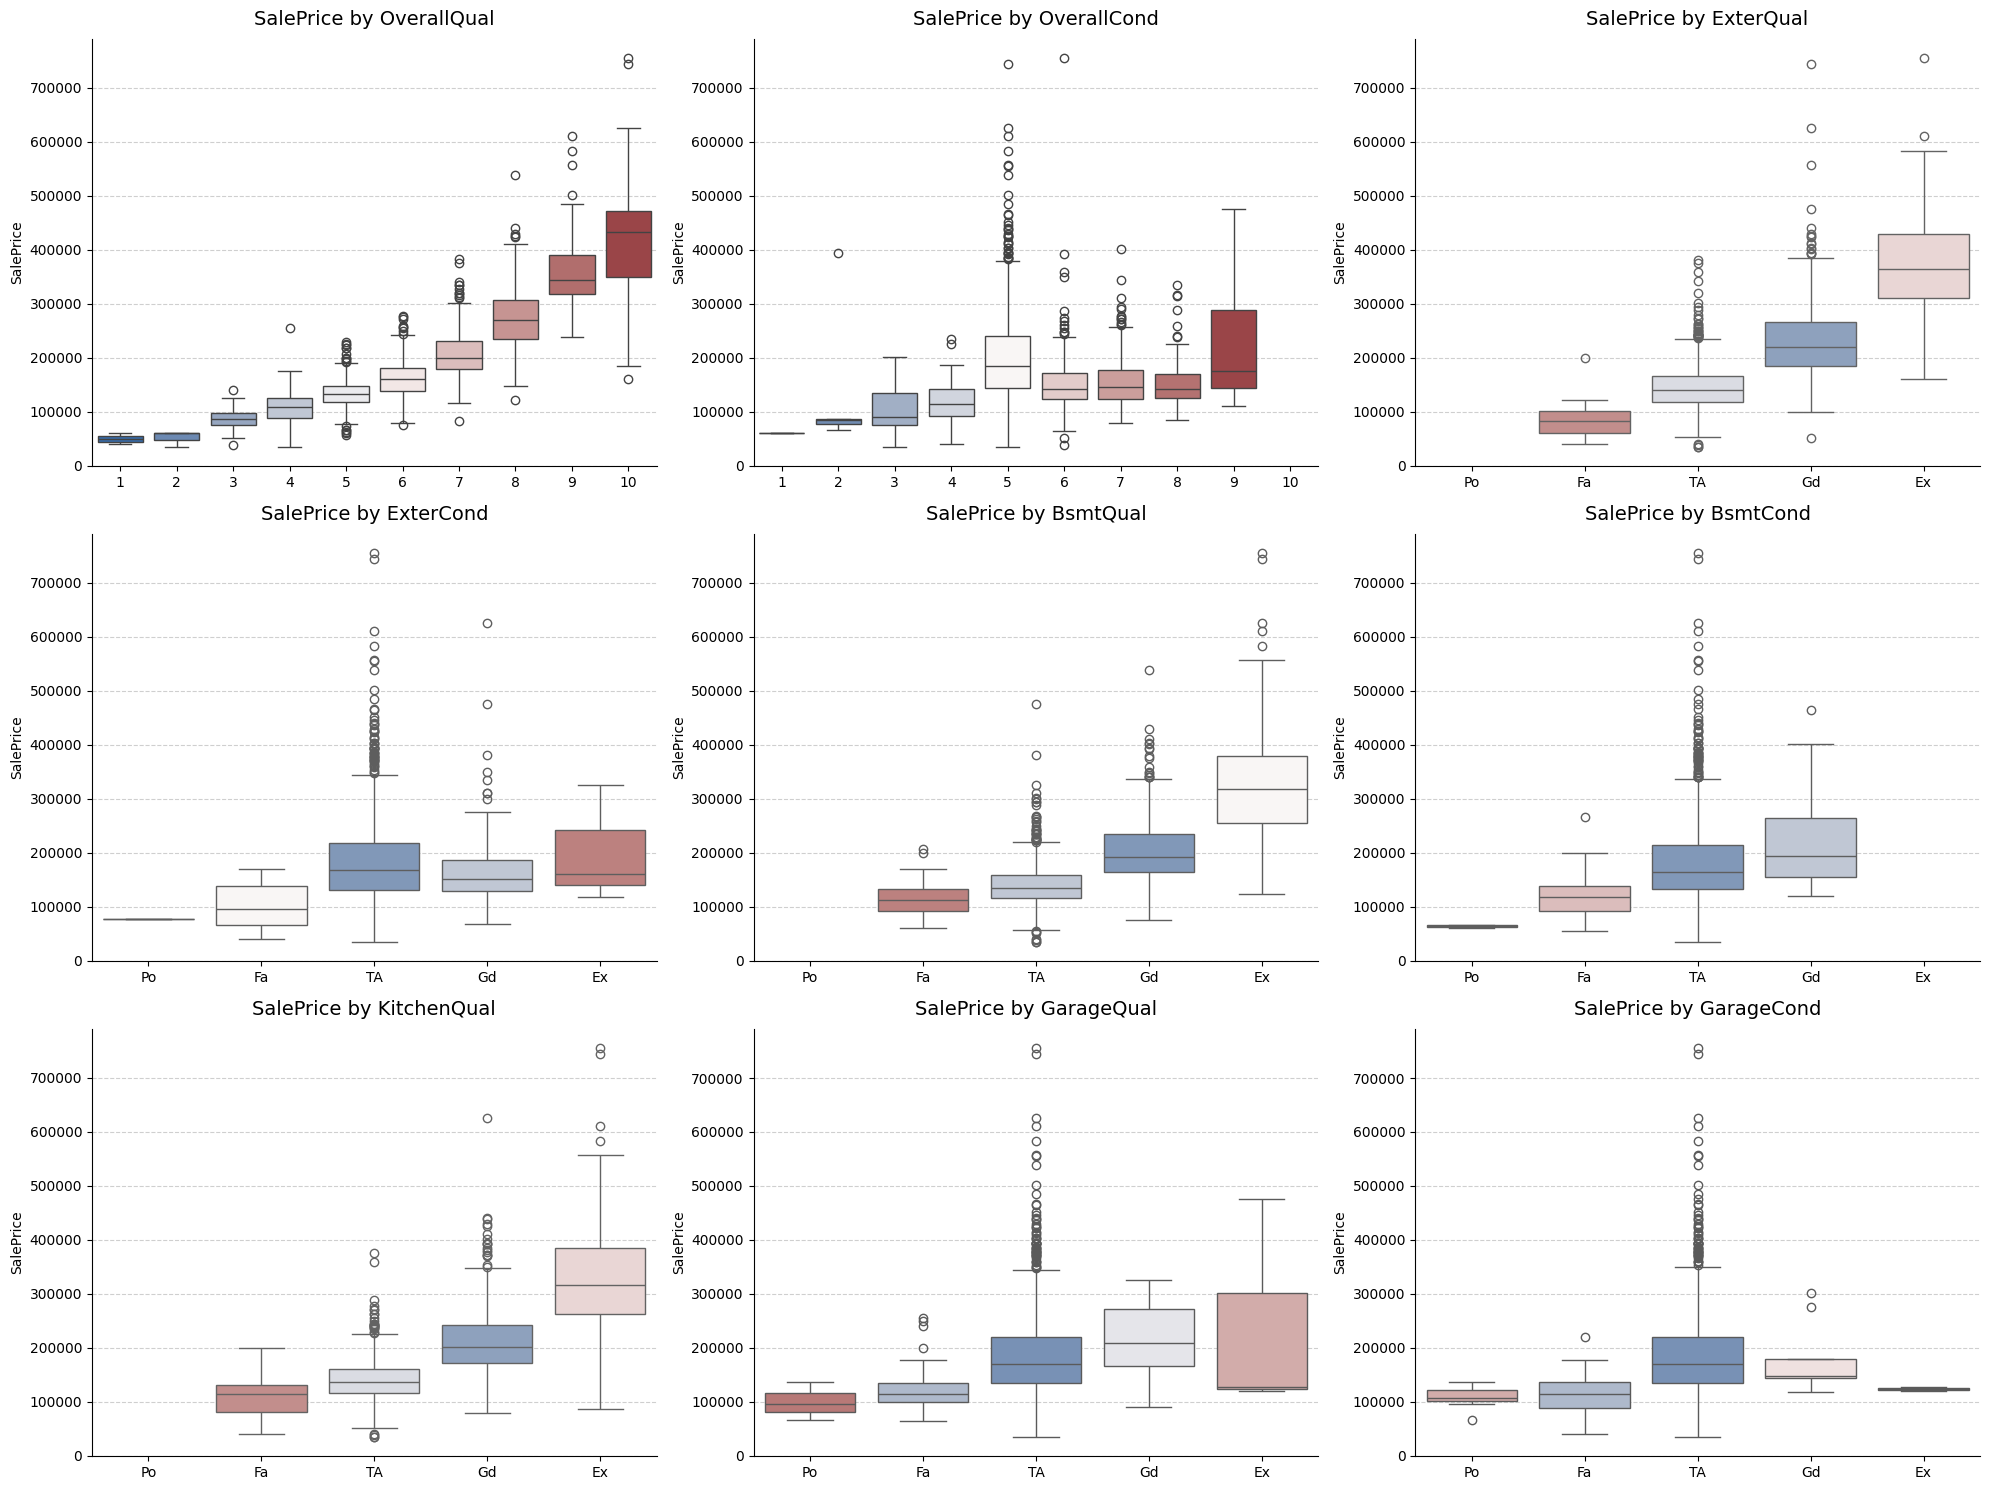

In [46]:
# Objetivo: criar boxplots de SalePrice por cada variável ordinal
n_vars = len(ordinal_order_map)
cols = 3
rows = math.ceil(n_vars / cols)

fig, axes = plt.subplots(rows, cols, figsize=(20, 5 * rows))
axes = axes.flatten()

# 2. Iteração direta no dicionário (chave e valor ao mesmo tempo)
for idx, (var, order) in enumerate(ordinal_order_map.items()):

    sns.boxplot(
        data=houses,
        x=var,
        y='SalePrice',
        order=order,
        ax=axes[idx],
        hue=var,
        palette='vlag',
        legend=False
    )

    # 4. Estilização limpa
    axes[idx].set_title(f'SalePrice by {var}', fontsize=14, pad=10)
    axes[idx].set_xlabel('')
    axes[idx].set_ylabel('SalePrice')
    axes[idx].tick_params(axis='x', rotation=0)
    axes[idx].grid(axis='y', linestyle='--', alpha=0.6)


for i in range(n_vars, len(axes)):
    fig.delaxes(axes[i])

sns.despine()

plt.tight_layout()
plt.show()

**Nota:** observamos muitos outliers em certas categorias das variáveis analisadas, como ``TA`` (Médio/Típico) na variável ``ExterCond`` (Condição do material no exterior), isso se deve à alta concentra

**Cálculo da correlação de Spearman:** O coeficiente de correlação de Spearman é definido como o coeficiente de correlação de Pearson entre as variáveis de postos.
A atribuição de postos (ou ranqueamento) é uma transformação de dados na qual dados numéricos ou ordinais são substituídos por sua posição quando os dados são ordenados.

In [47]:
# Objetivo: codificar variáveis ordinais em números e calcular Spearman com SalePrice
ordinal_vars_cell28 = [
    'OverallQual', 'OverallCond', 'ExterQual', 'ExterCond',
    'BsmtQual', 'BsmtCond', 'KitchenQual', 'GarageQual', 'GarageCond'
 ]

# Mapeamento ordinal (inclui 'None' como 0 para representar ausência quando aplicável)
quality_map = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}

ordinal_numeric = houses[ordinal_vars_cell28].copy()

# Variáveis já numéricas no dataset
ordinal_numeric['OverallQual'] = pd.to_numeric(ordinal_numeric['OverallQual'], errors='coerce')
ordinal_numeric['OverallCond'] = pd.to_numeric(ordinal_numeric['OverallCond'], errors='coerce')

# Variáveis ordinais categóricas
for col in ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'KitchenQual', 'GarageQual', 'GarageCond']:
    ordinal_numeric[col] = ordinal_numeric[col].map(quality_map)

# Junta com a variável alvo e calcula Spearman
spearman_df = ordinal_numeric.copy()
spearman_df['SalePrice'] = houses['SalePrice']

spearman_results = spearman_df.corr(method='spearman')['SalePrice'].drop('SalePrice').sort_values(ascending=False)

print('Spearman das variáveis ordinais (Cell 28) com SalePrice:')
print(spearman_results.to_frame(name='Spearman_corr'))

Spearman das variáveis ordinais (Cell 28) com SalePrice:
             Spearman_corr
OverallQual       0.809829
ExterQual         0.684014
BsmtQual          0.678026
KitchenQual       0.672849
GarageQual        0.351082
GarageCond        0.339015
BsmtCond          0.269373
ExterCond         0.011682
OverallCond      -0.129325


### **Conclusão Geral da Análise Exploratória de Dados (EDA)**

Com a conclusão desta análise exploratória, tivemos o primeiro contato com o comportamento do mercado imobiliário de Ames, identificando os fatores mais críticos que ditam a formação do preço de venda das casas (`SalePrice`). O estudo das variáveis numéricas, categóricas e ordinais nos forneceu insights que guiarão diretamente a próxima etapa de modelagem preditiva.

#### **1. Os Principais Vetores de Valor**
A análise demonstrou que o preço de um imóvel é definido primordialmente pela combinação de dimensões físicas e qualidade estrutural:
* **Dimensões Físicas:** A Área Habitável acima do solo (`GrLivArea`) e a Área Total do Porão (`TotalBsmtSF`) mostraram as correlações lineares mais fortes com o preço (destacando-se o coeficiente de 0.71 de `GrLivArea`). Casas sem porão ou sem garagem (`HasGarage`) sofrem uma severa penalização e ficam confinadas aos menores valores do dataset.
* **Qualidade e Localização:** Entre as variáveis qualitativas, a Qualidade Geral do material e acabamento (`OverallQual`) provou ser o indicador mais robusto através do coeficiente de Spearman. Além disso, o bairro (`Neighborhood`) e o tipo de zona (`MSZoning`) mostraram um potencial descritivo, dividindo o mercado de Ames entre bairros de luxo e regiões populares.

#### **2. Diretrizes Estratégicas para a Etapa de Modelagem (Machine Learning)**
Para garantir a estabilidade e a performance dos futuros modelos de regressão, os seguintes tratamentos poderão ser adotados com base nos diagnósticos estatísticos realizados:
* **Tratamento de Outliers:** É fundamental realizar a remoção ou tratamento dos dois outliers identificados nos gráficos de dispersão (imóveis com mais de 4.500 sqft de área útil vendidos por valores atipicamente baixos). Manter esses pontos quebraria as suposições de linearidade de algoritmos de regressão.
* **Correção de Multicolinearidade:** Como identificado no Heatmap, variáveis redundantes como `GarageCars` e `GarageArea` possuem uma correlação extrema (0.88). Para evitar variância inflada no modelo, é possível manter apenas uma delas (preferencialmente `GarageCars`).
* **Simplificação Categórica e Ordinal:** Bairros com baixíssima frequência (menos de 30 instâncias, como `Blueste` e `NPkVill`) podem ser agrupados em uma categoria comum ("Outros") para evitar sobreajuste (*overfitting*). Da mesma forma, variáveis ordinais com variância quase nula (onde a grande maioria das casas recebe a mesma nota, como `GarageCond` e `GarageQual`) podem ser descartadas, pois não agregam poder preditivo.

Em suma, a base de dados foi saneada de valores nulos. Além disso, relações e anomalias foram geometricamente identificadas e os dados encontram-se prontos para a fase seguinte.